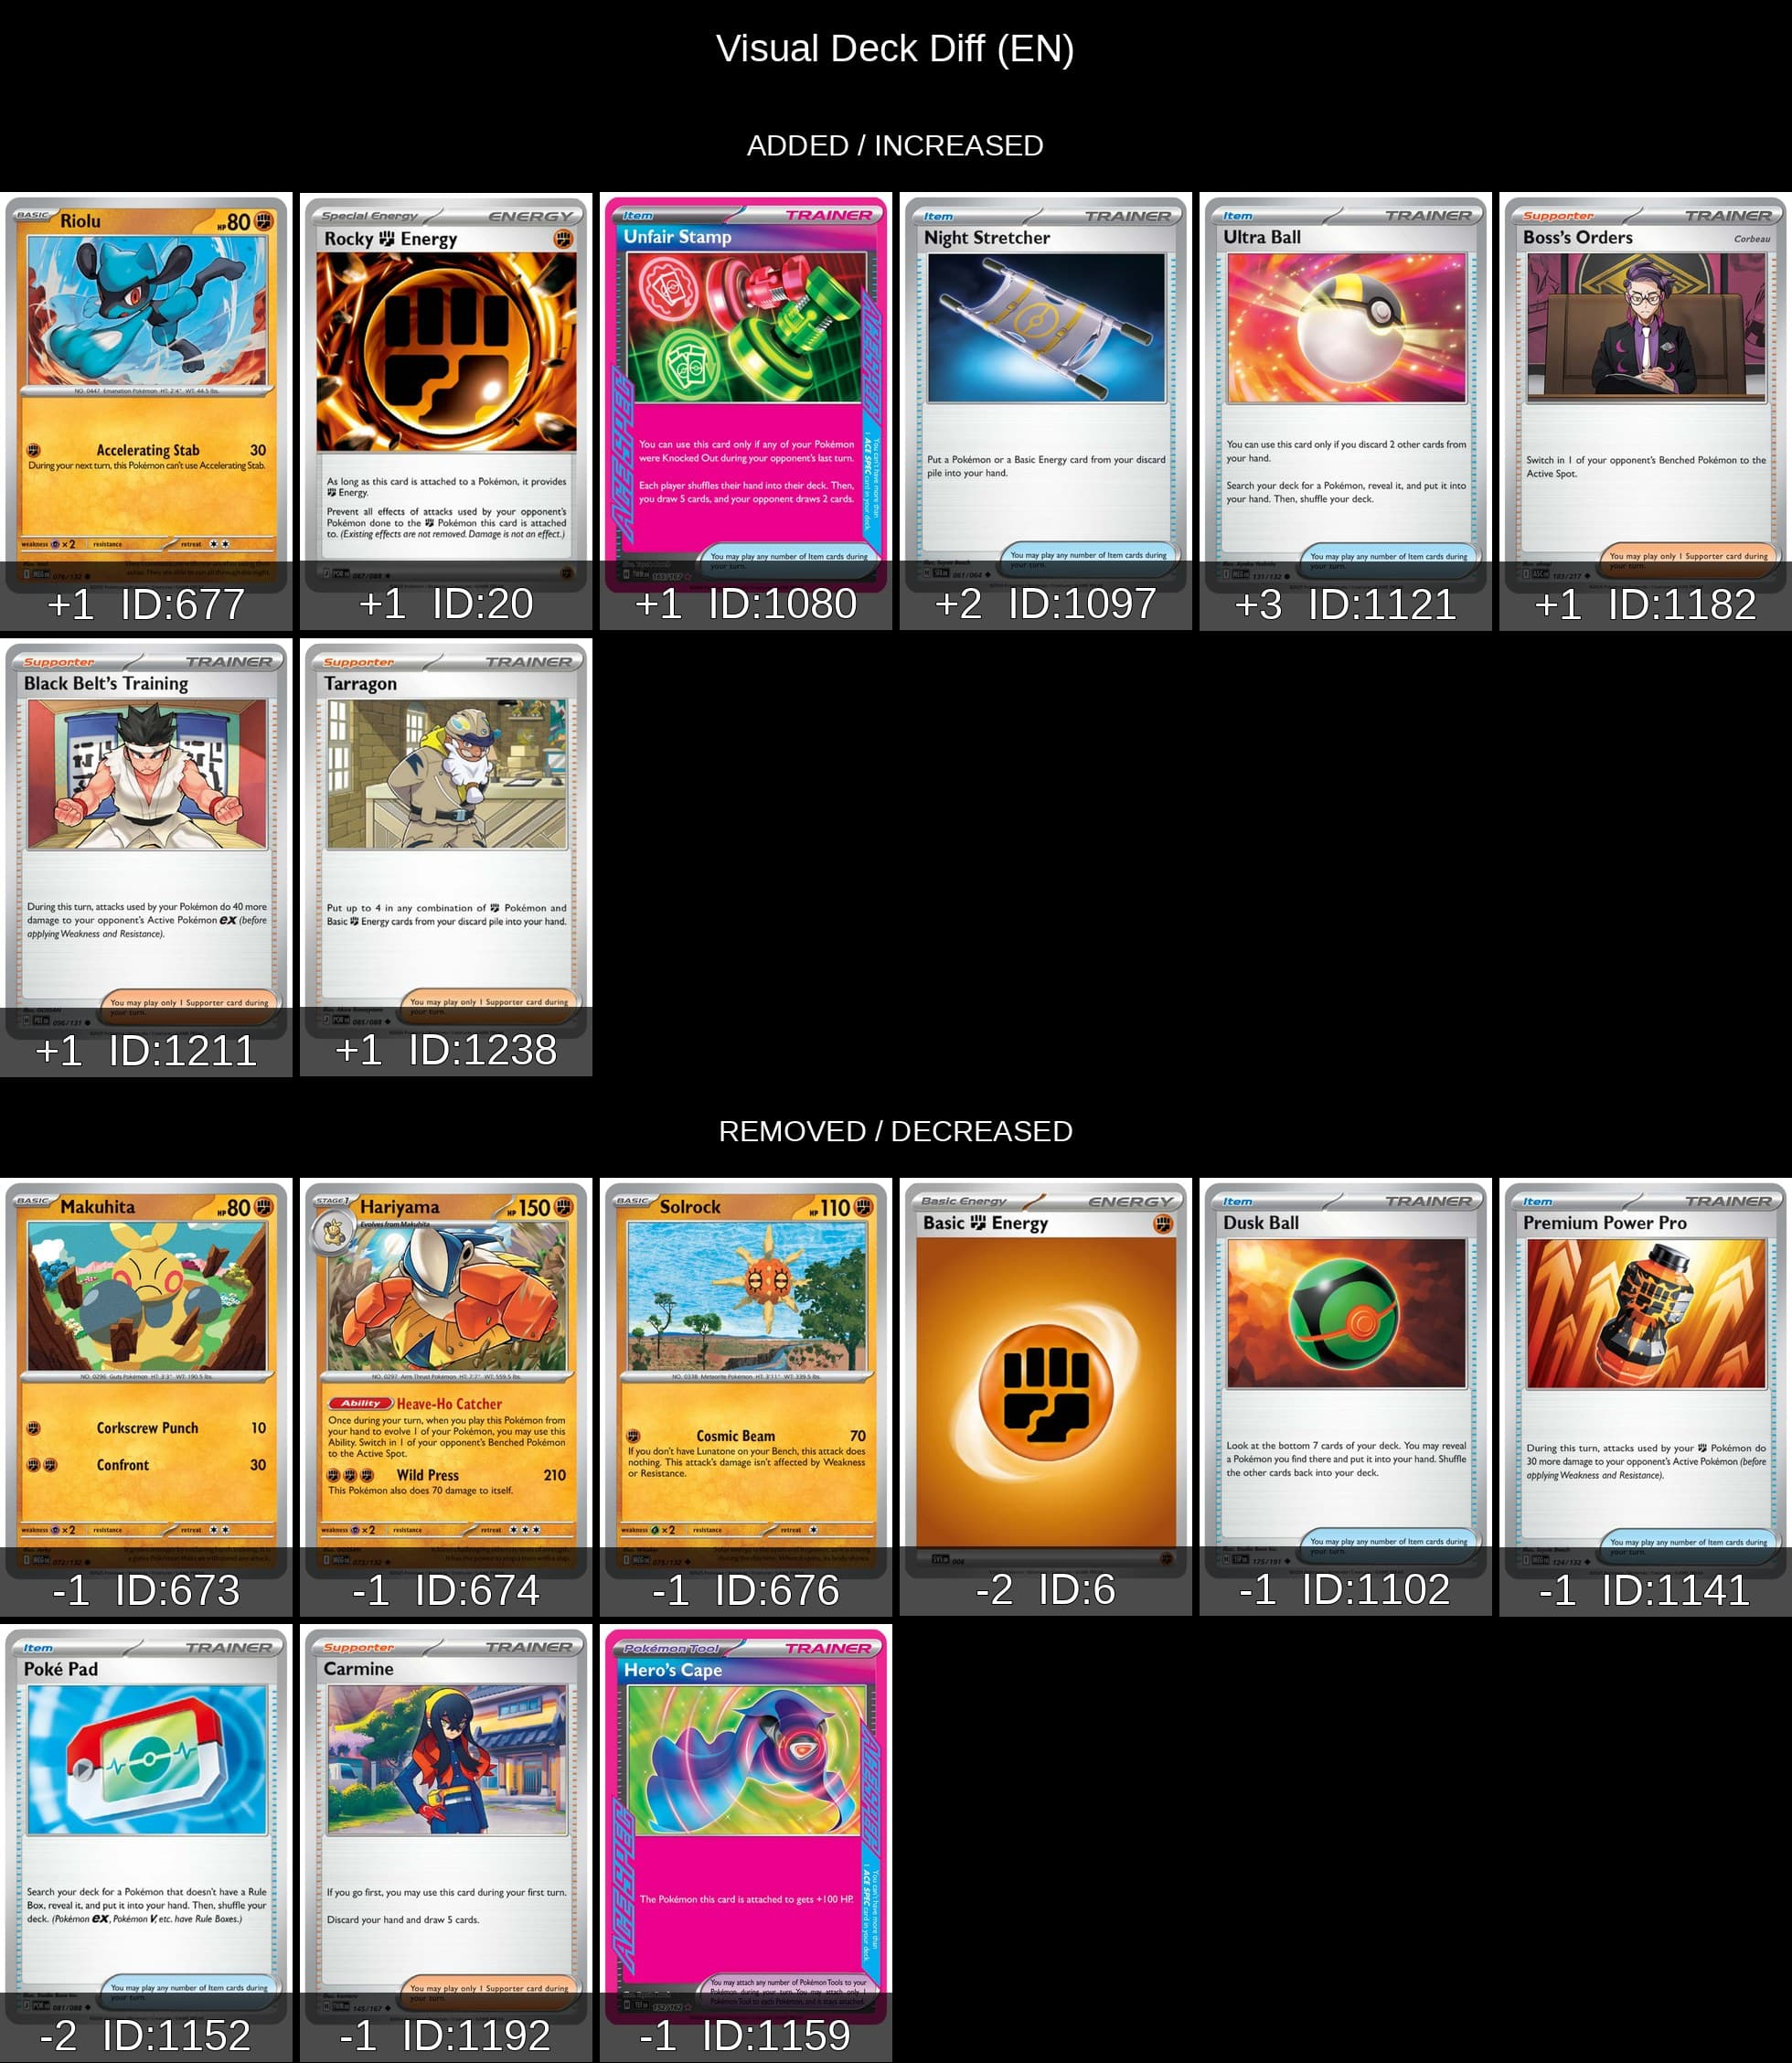

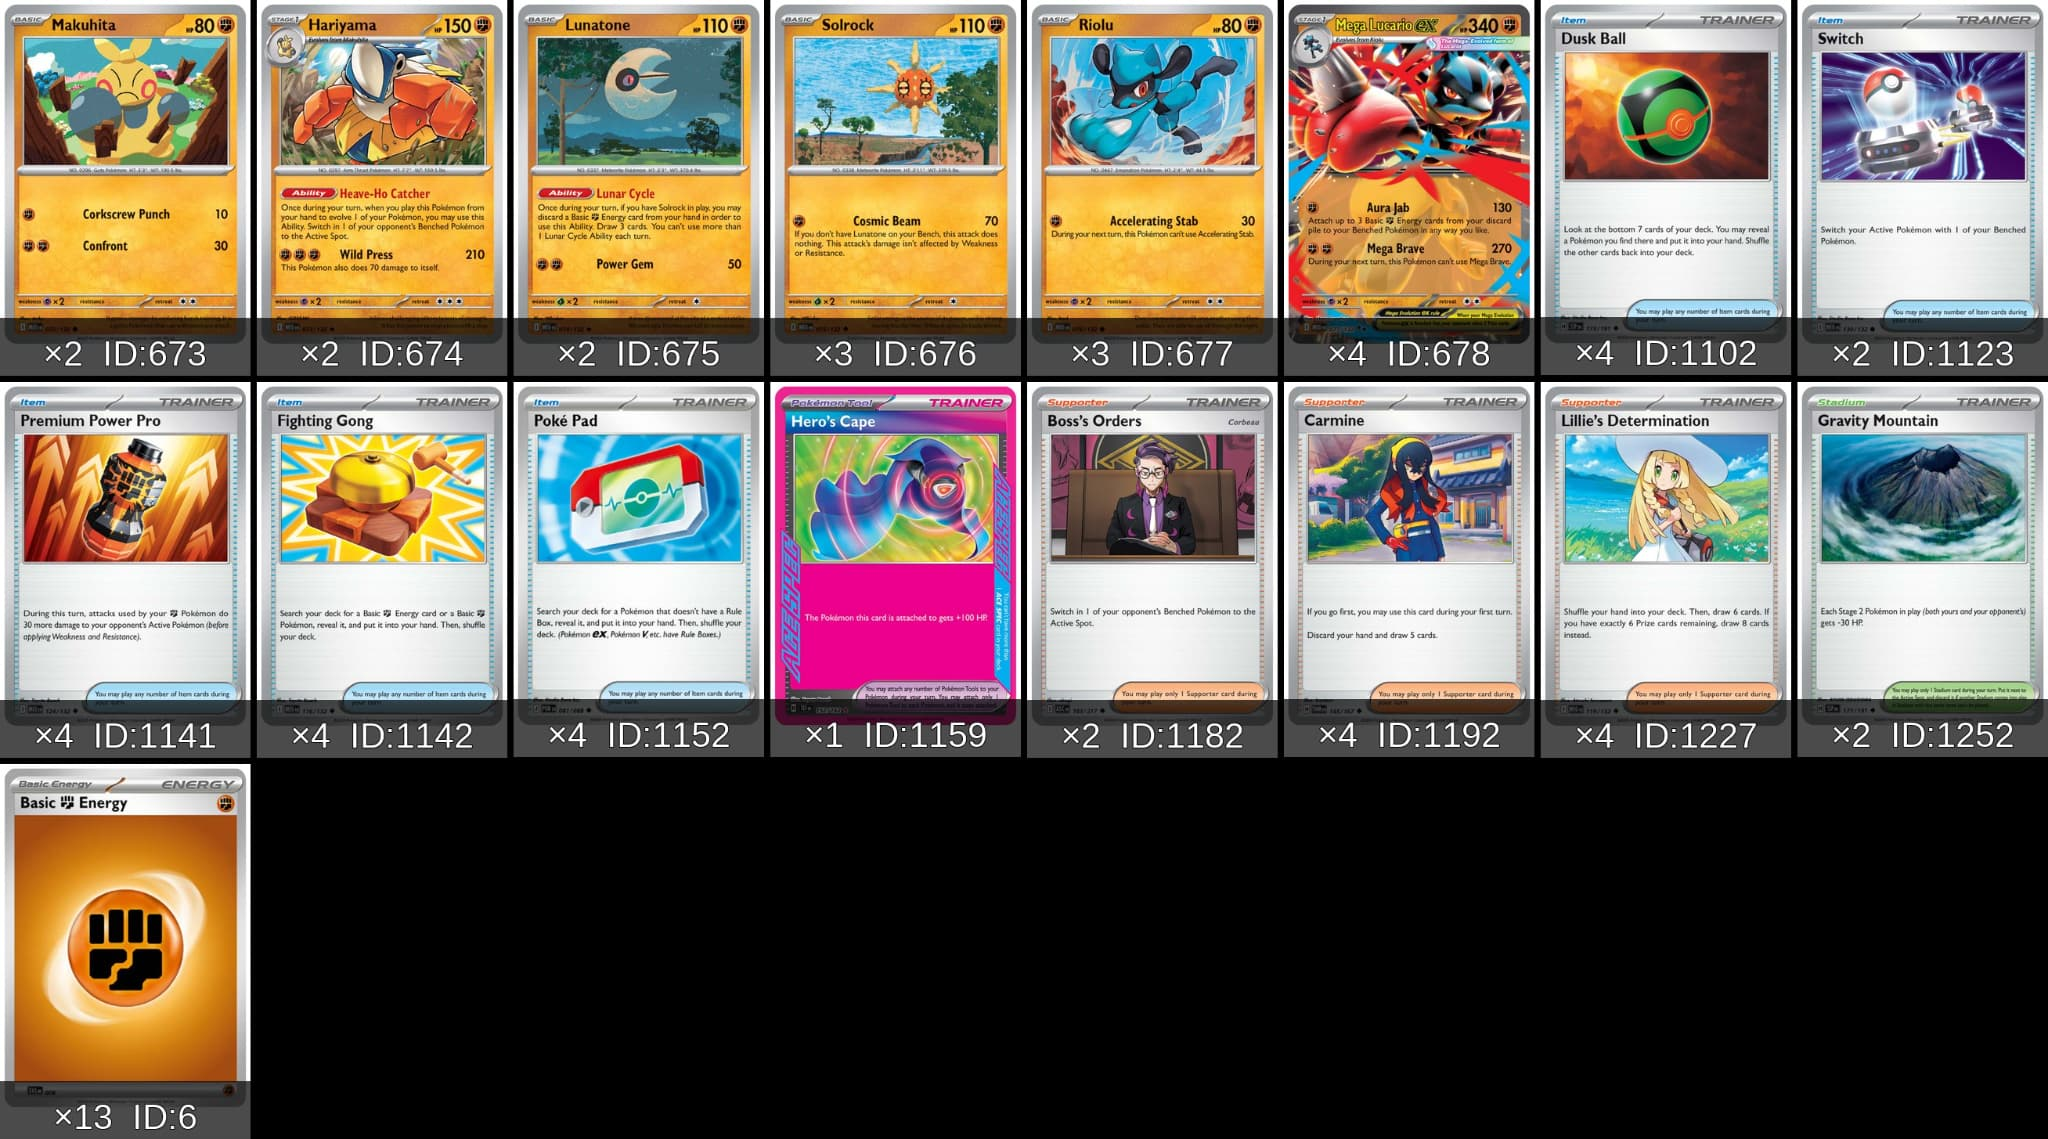

# Pokémon TCG Deck Image Renderer + Visual Deck Diff

This notebook turns a 60-card Pokémon TCG deck list into shareable card images.

It now also compares two deck lists and shows the visual difference.


## What changed from the previous version

Previous version:

- Render one deck as `deck_en.jpg`
- Render one deck as `deck_jp.jpg`
- Write a simple `deck.csv`

This version adds:

- Visual deck comparison between `BEFORE_DECK` and `AFTER_DECK`
- `deck_diff_en.jpg` and `deck_diff_jp.jpg`
- `deck_diff.csv` for exact count changes
- `deck_changelog.md` for Kaggle Discussion or notebook comments
- A realistic Lucario demo diff that keeps Mega Lucario ex as the main attacker

This notebook still does **not** run battles, agents, self-play, or simulations.
It is only a deck visualization and comparison utility.


## How to use this notebook

There are two independent parts.

### Part A: render one deck

Use `HARD_CODED_DECK` or an external `deck.csv`.
The notebook writes `deck.csv`, then renders:

- `deck_en.jpg`
- `deck_jp.jpg`

### Part B: compare two decks

Use the demo lists:

- `BEFORE_DECK`
- `AFTER_DECK`

The notebook renders the visual diff:

- `deck_diff_en.jpg`
- `deck_diff_jp.jpg`
- `deck_diff.csv`
- `deck_changelog.md`

The demo is intentionally simple:

> current Lucario list → consistency and recovery Lucario list

You can replace the Card IDs later with your own deck versions.


In [ ]:
!pip install pymupdf

In [ ]:
import os
from pathlib import Path

# -----------------------------------------------------------------------------
# Part A: one-deck rendering setup
# -----------------------------------------------------------------------------
# Set this to True if you want to render an existing deck.csv from an attached
# Kaggle dataset. For the public demo, the hardcoded Lucario deck is easier.
USE_EXTERNAL_DECK_CSV = False

EXTERNAL_DECK_CANDIDATES = [
    "/kaggle/input/datasets/kiyotah/mega-lucario-ex-deck/deck.csv",
    "/kaggle/input/mega-lucario-ex-deck/deck.csv",
    "deck.csv",
]

# Current Lucario deck used by the original notebook.
# This remains the default deck used for deck.csv, deck_en.jpg, and deck_jp.jpg.
HARD_CODED_DECK = [
    673, 673, 674, 674, 675, 675, 676, 676,
    676, 677, 677, 677, 678, 678, 678, 678,
    1102, 1102, 1102, 1102, 1123, 1123, 1141, 1141,
    1141, 1141, 1142, 1142, 1142, 1142, 1152, 1152,
    1152, 1152, 1159, 1182, 1182, 1192, 1192, 1192,
    1192, 1227, 1227, 1227, 1227, 1252, 1252, 6,
    6, 6, 6, 6, 6, 6, 6, 6,
    6, 6, 6, 6,
]

# -----------------------------------------------------------------------------
# Part B: visual deck diff demo setup
# -----------------------------------------------------------------------------
# The diff demo is independent from the main deck renderer.
# It compares BEFORE_DECK and AFTER_DECK and creates deck_diff_* outputs.
ENABLE_DECK_DIFF = True

# BEFORE_DECK is intentionally the current Lucario list.
BEFORE_DECK = list(HARD_CODED_DECK)

# AFTER_DECK keeps Mega Lucario ex as the main attacker, but shifts the deck
# toward consistency and recovery:
# - +1 Riolu
# - +3 Ultra Ball
# - +2 Night Stretcher
# - ACE SPEC: Hero's Cape -> Unfair Stamp
# - slightly trims the Hariyama package, Poké Pad, Carmine, and Fighting Energy
AFTER_DECK = [
    # Pokémon
    673,
    674,
    675, 675,
    676, 676,
    677, 677, 677, 677,
    678, 678, 678, 678,

    # Energy
    20,
    6, 6, 6, 6, 6, 6, 6, 6,
    6, 6, 6,

    # Trainers / Items / Tools / Stadium / Supporters
    1080,
    1097, 1097,
    1102, 1102, 1102,
    1121, 1121, 1121,
    1123, 1123,
    1141, 1141, 1141,
    1142, 1142, 1142, 1142,
    1152, 1152,
    1182, 1182, 1182,
    1192, 1192, 1192,
    1211,
    1227, 1227, 1227, 1227,
    1238,
    1252, 1252,
]

if USE_EXTERNAL_DECK_CSV:
    deck_path = next((p for p in EXTERNAL_DECK_CANDIDATES if os.path.exists(p)), None)
    if deck_path is None:
        raise FileNotFoundError(
            "No external deck.csv was found. "
            "Set USE_EXTERNAL_DECK_CSV = False or add a dataset containing deck.csv."
        )

    with open(deck_path, "r", encoding="utf-8") as f:
        deck = [int(x) for x in f.read().splitlines() if x.strip()]
    deck_source = deck_path
else:
    deck = list(HARD_CODED_DECK)
    deck_source = "HARD_CODED_DECK"

if len(deck) != 60:
    raise ValueError(f"A deck must contain exactly 60 cards, but got {len(deck)} cards.")

if ENABLE_DECK_DIFF:
    if len(BEFORE_DECK) != 60:
        raise ValueError(f"BEFORE_DECK must contain exactly 60 cards, but got {len(BEFORE_DECK)} cards.")
    if len(AFTER_DECK) != 60:
        raise ValueError(f"AFTER_DECK must contain exactly 60 cards, but got {len(AFTER_DECK)} cards.")

with open("deck.csv", "w", encoding="utf-8") as f:
    for card_id in deck:
        f.write(f"{int(card_id)}\n")

print("Deck source:", deck_source)
print("Deck size:", len(deck))
print("First 10 Card IDs:", deck[:10])
print("deck.csv written to:", Path("deck.csv").resolve())
print("Visual deck diff enabled:", ENABLE_DECK_DIFF)
if ENABLE_DECK_DIFF:
    print("BEFORE_DECK size:", len(BEFORE_DECK))
    print("AFTER_DECK size:", len(AFTER_DECK))


## Important note about the card CSV files

`deck.csv` is simple.  
It is just a 60-line list of Card IDs, so reading it with `splitlines()` is fine.

The official card data CSV files are different.

They can contain quoted multiline text, for example an effect explanation with line breaks inside one CSV field.  
So we should **not** parse the card data CSV with `splitlines()`.

This notebook reads card data with `pandas.read_csv`, which understands quoted multiline CSV fields.


## Image and output settings

The paths below assume the competition dataset is attached to the Kaggle Notebook.

The key assumption is:

> PDF page 40 is the first unique card in the card CSV.

The page number here is human-style, 1-indexed.  
Python PDF libraries use 0-indexed page indices internally, so the code handles that conversion.

The same PDF cropping logic is used for both:

- normal deck images
- visual deck diff images


In [ ]:
from pathlib import Path

COMPETITION_INPUT_DIR = Path("/kaggle/input/competitions/pokemon-tcg-ai-battle")

CARD_CSV_EN = COMPETITION_INPUT_DIR / "EN_Card_Data.csv"
CARD_CSV_JP = COMPETITION_INPUT_DIR / "JP_Card_Data.csv"

CARD_PDF_EN = COMPETITION_INPUT_DIR / "Card_ID List_EN.pdf"
CARD_PDF_JP = COMPETITION_INPUT_DIR / "Card_ID List_JP.pdf"

# Human-readable PDF page number.
# If PDF page 40 corresponds to the first unique Card ID in the CSV, keep this as 40.
PDF_CARD_START_PAGE = 40

# Normal deck image outputs
OUTPUT_EN = Path("deck_en.jpg")
OUTPUT_JP = Path("deck_jp.jpg")

# Visual deck diff outputs
OUTPUT_DIFF_EN = Path("deck_diff_en.jpg")
OUTPUT_DIFF_JP = Path("deck_diff_jp.jpg")
OUTPUT_DIFF_CSV = Path("deck_diff.csv")
OUTPUT_CHANGELOG_MD = Path("deck_changelog.md")

GRID_COLUMNS = 8
CARD_DISPLAY_WIDTH = 320
GRID_GAP = 8
GRID_PADDING = 0

# Diff images usually contain fewer cards, so 6 columns are easier to read.
DIFF_GRID_COLUMNS = 6

LABEL_ALPHA = 180
PAGE_RENDER_ZOOM = 4.0

# JPG output settings
MAX_OUTPUT_BYTES = 1_000_000  # 1MB
JPEG_START_QUALITY = 88
JPEG_MIN_QUALITY = 45
JPEG_DOWNSCALE_STEP = 0.92
JPEG_MIN_WIDTH = 1200

print("English CSV:", CARD_CSV_EN)
print("Japanese CSV:", CARD_CSV_JP)
print("English PDF:", CARD_PDF_EN)
print("Japanese PDF:", CARD_PDF_JP)
print("Output EN:", OUTPUT_EN.resolve())
print("Output JP:", OUTPUT_JP.resolve())
print("Output diff EN:", OUTPUT_DIFF_EN.resolve())
print("Output diff JP:", OUTPUT_DIFF_JP.resolve())
print("Output diff CSV:", OUTPUT_DIFF_CSV.resolve())
print("Output changelog:", OUTPUT_CHANGELOG_MD.resolve())


## Helper functions

The functions below do six things:

1. Get the deck from the notebook variable `deck`, or from `deck.csv`.
2. Read the official card data CSV safely.
3. Convert Card IDs to PDF page indices.
4. Crop card images from the official PDF.
5. Render a normal deck grid.
6. Render a visual deck diff grid and write a small changelog.

The diff functions reuse the same CSV/PDF mapping logic as the original renderer.
That keeps the new feature small and avoids changing the existing deck image behavior.


In [ ]:
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown


def resolve_deck_ids(deck_csv_path="deck.csv"):
    """Return the 60-card deck list.

    Priority:
    1. Use the notebook variable named `deck` if it exists.
    2. Otherwise read deck.csv.

    This makes the renderer work with both hardcoded decks and external deck.csv files.
    """
    if "deck" in globals():
        deck_ids = list(globals()["deck"])
        source = "notebook variable: deck"
    else:
        deck_csv_path = Path(deck_csv_path)
        if not deck_csv_path.exists():
            raise FileNotFoundError(
                "No notebook variable named `deck` was found, and deck.csv does not exist."
            )
        with open(deck_csv_path, "r", encoding="utf-8") as f:
            deck_ids = [line.strip() for line in f.read().splitlines() if line.strip()]
        source = str(deck_csv_path)

    try:
        deck_ids = [int(x) for x in deck_ids]
    except Exception as e:
        raise ValueError("Deck must contain Card IDs that can be converted to integers.") from e

    if len(deck_ids) != 60:
        raise ValueError(f"A deck must contain exactly 60 cards, but got {len(deck_ids)} cards.")

    return deck_ids, source


def ordered_deck_counts(deck_ids):
    """Count Card IDs while preserving first appearance order."""
    counts = Counter(deck_ids)
    ordered_ids = []
    seen = set()

    for card_id in deck_ids:
        if card_id not in seen:
            ordered_ids.append(card_id)
            seen.add(card_id)

    return ordered_ids, counts


def normalize_column_name(name):
    """Normalize a column name for safer matching.

    This helps with small differences such as:
    - BOM
    - leading/trailing spaces
    - half-width spaces
    - full-width spaces
    """
    return (
        str(name)
        .strip()
        .lstrip("\ufeff")
        .replace(" ", "")
        .replace("　", "")
        .lower()
    )


def find_column(df, candidates, label):
    """Find a column by trying exact and normalized matching."""
    columns = list(df.columns)

    cleaned_to_original = {
        str(col).strip().lstrip("\ufeff"): col
        for col in columns
    }

    for candidate in candidates:
        if candidate in cleaned_to_original:
            return cleaned_to_original[candidate]

    normalized_to_original = {
        normalize_column_name(col): col
        for col in columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_column_name(candidate)
        if normalized_candidate in normalized_to_original:
            return normalized_to_original[normalized_candidate]

    raise ValueError(
        f"{label} column was not found. "
        f"Candidates: {candidates}. "
        f"Columns found: {columns}"
    )


def read_card_data_csv(csv_path):
    """Read official Card Data CSV safely.

    The official CSV may contain quoted multiline fields.
    Do not parse it with splitlines().

    This function supports both English and Japanese column names.

    English:
      - Card ID
      - Card Name

    Japanese:
      - カード ID
      - カード名
    """
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"Card data CSV not found: {csv_path}")

    errors = []

    for engine in ["c", "python"]:
        try:
            df = pd.read_csv(
                csv_path,
                encoding="utf-8-sig",
                keep_default_na=False,
                engine=engine,
            )
            break
        except Exception as e:
            errors.append(f"engine={engine}: {repr(e)}")
    else:
        raise RuntimeError(
            "Could not parse card data CSV. Errors:\n" + "\n".join(errors)
        )

    df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]

    card_id_col = find_column(
        df,
        candidates=[
            "Card ID",
            "カード ID",
            "カードID",
        ],
        label="Card ID",
    )

    try:
        card_name_col = find_column(
            df,
            candidates=[
                "Card Name",
                "カード名",
            ],
            label="Card Name",
        )
    except ValueError:
        card_name_col = None

    card_id_numeric = pd.to_numeric(df[card_id_col], errors="coerce")
    valid = card_id_numeric.notna()

    if not valid.any():
        raise ValueError(f"No valid Card ID values were found in {csv_path}")

    df = df.loc[valid].copy()
    df["Card ID"] = card_id_numeric.loc[valid].astype(int)

    if card_name_col is not None:
        df["Card Name"] = df[card_name_col].astype(str)
    else:
        df["Card Name"] = ""

    return df


def load_unique_card_order(csv_path):
    """Return unique Card IDs in first appearance order.

    The card data CSV can have multiple rows for one Card ID because one card can have
    multiple attacks or effects. The PDF order should correspond to unique Card IDs,
    not raw CSV rows.
    """
    df = read_card_data_csv(csv_path)

    unique_df = df.drop_duplicates(subset=["Card ID"], keep="first").reset_index(drop=True)
    unique_card_ids = unique_df["Card ID"].astype(int).tolist()

    card_id_to_order = {
        card_id: i
        for i, card_id in enumerate(unique_card_ids)
    }

    card_names = dict(
        zip(
            unique_df["Card ID"].astype(int),
            unique_df["Card Name"].astype(str),
        )
    )

    return unique_card_ids, card_id_to_order, card_names, len(df)


def build_card_id_to_pdf_page_index(deck_unique_ids, card_id_to_order, pdf_card_start_page=40):
    """Map Card ID to 0-indexed PDF page index."""
    missing = [
        card_id
        for card_id in deck_unique_ids
        if card_id not in card_id_to_order
    ]

    if missing:
        raise ValueError(
            "These deck Card IDs were not found in the card data CSV: "
            + ", ".join(map(str, missing))
        )

    # pdf_card_start_page is 1-indexed.
    start_page_index = pdf_card_start_page - 1

    return {
        card_id: start_page_index + card_id_to_order[card_id]
        for card_id in deck_unique_ids
    }


def import_pymupdf():
    """Import PyMuPDF with a beginner-friendly error message."""
    try:
        import fitz
        return fitz
    except Exception as e:
        raise ImportError(
            "PyMuPDF is required to render PDF pages. "
            "In Kaggle, try adding a cell with `pip install pymupdf` if it is not available."
        ) from e


def render_pdf_page_to_image(doc, page_index, zoom=4.0):
    """Render one PDF page to a PIL RGB image."""
    if page_index < 0 or page_index >= len(doc):
        raise IndexError(
            f"PDF page index out of range: {page_index}. "
            f"The PDF has {len(doc)} pages."
        )

    page = doc.load_page(page_index)
    fitz = import_pymupdf()
    matrix = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=matrix, alpha=False)

    img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    return img


def crop_card_from_page_image(page_img, expected_card_aspect=0.714):
    """Crop the card image from a rendered PDF page.

    The official PDF page is mostly white, with one card near the upper-middle area.

    This version is intentionally a little stricter than a simple bounding box.
    It tries to remove extra white margins on the left and right, then enforces
    a Pokémon-card-like portrait aspect ratio.
    """
    img = page_img.convert("RGB")
    arr = np.asarray(img)

    h, w = arr.shape[:2]

    # Search only where the card is expected to be.
    # The bottom note text is intentionally excluded.
    x0 = int(w * 0.05)
    x1 = int(w * 0.95)
    y0 = int(h * 0.02)
    y1 = int(h * 0.72)

    roi = arr[y0:y1, x0:x1, :]

    # Difference from white background.
    # This is more stable than checking one channel only.
    darkness = np.max(255 - roi.astype(np.int16), axis=2)

    # Card art/text/border should differ from the white PDF background.
    mask = darkness > 18

    row_counts = mask.sum(axis=1)
    col_counts = mask.sum(axis=0)

    if row_counts.max() <= 0 or col_counts.max() <= 0:
        # Fallback crop based on the sample layout.
        left = int(w * 0.36)
        right = int(w * 0.64)
        top = int(h * 0.07)
        bottom = int(h * 0.62)
    else:
        # Use density thresholds instead of a raw bounding box.
        # This avoids tiny text/noise expanding the crop.
        row_threshold = max(10, int(row_counts.max() * 0.055))
        col_threshold = max(10, int(col_counts.max() * 0.055))

        ys = np.where(row_counts > row_threshold)[0]
        xs = np.where(col_counts > col_threshold)[0]

        if len(xs) < 10 or len(ys) < 10:
            # Fallback crop based on the sample layout.
            left = int(w * 0.36)
            right = int(w * 0.64)
            top = int(h * 0.07)
            bottom = int(h * 0.62)
        else:
            left = x0 + int(xs.min())
            right = x0 + int(xs.max()) + 1
            top = y0 + int(ys.min())
            bottom = y0 + int(ys.max()) + 1

            # Add a small margin so the card border is not accidentally cut off.
            pad = max(8, int(max(w, h) * 0.004))
            left = max(0, left - pad)
            right = min(w, right + pad)
            top = max(0, top - pad)
            bottom = min(h, bottom + pad)

    # The most common failure mode is that the crop is too wide because the page
    # contains a little non-white noise. We tighten the width toward the expected
    # Pokémon card aspect ratio.
    box_w = right - left
    box_h = bottom - top

    if box_w <= 0 or box_h <= 0:
        raise RuntimeError("Invalid crop box. Check the PDF page mapping or crop logic.")

    current_aspect = box_w / box_h
    center_x = (left + right) / 2

    # If crop is too wide, shrink horizontally around the detected center.
    if current_aspect > expected_card_aspect * 1.18:
        target_w = int(round(box_h * expected_card_aspect))
        left = int(round(center_x - target_w / 2))
        right = left + target_w

    # If crop is too narrow, expand horizontally. This is safer than cropping height.
    elif current_aspect < expected_card_aspect * 0.82:
        target_w = int(round(box_h * expected_card_aspect))
        left = int(round(center_x - target_w / 2))
        right = left + target_w

    # Clamp to page bounds.
    if left < 0:
        right -= left
        left = 0

    if right > w:
        shift = right - w
        left = max(0, left - shift)
        right = w

    # Final tiny padding. At high zoom this keeps the border safe without bringing
    # back large side margins.
    final_pad = max(2, int(max(w, h) * 0.0015))
    left = max(0, left - final_pad)
    right = min(w, right + final_pad)
    top = max(0, top - final_pad)
    bottom = min(h, bottom + final_pad)

    cropped = img.crop((left, top, right, bottom))

    if cropped.width < 50 or cropped.height < 80:
        raise RuntimeError(
            f"Card crop looks too small: {cropped.size}. "
            "Check PDF_CARD_START_PAGE or the crop logic."
        )

    return cropped


def extract_card_images_from_pdf(pdf_path, card_id_to_page_index, zoom=4.0):
    """Extract only the PDF pages needed by the deck."""
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"Card PDF not found: {pdf_path}")

    fitz = import_pymupdf()
    images = {}

    with fitz.open(pdf_path) as doc:
        for card_id, page_index in card_id_to_page_index.items():
            page_img = render_pdf_page_to_image(doc, page_index, zoom=zoom)
            card_img = crop_card_from_page_image(page_img)
            images[card_id] = card_img

    return images


def get_font(size):
    """Get a readable font. Fall back to PIL default if needed."""
    font_candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
    ]

    for font_path in font_candidates:
        if Path(font_path).exists():
            try:
                return ImageFont.truetype(font_path, size=size)
            except Exception:
                pass

    return ImageFont.load_default()


def resize_keep_aspect(img, target_width):
    """Resize an image while preserving aspect ratio."""
    resampling = getattr(Image, "Resampling", Image).LANCZOS
    target_width = int(target_width)
    scale = target_width / img.width
    target_height = max(1, int(round(img.height * scale)))
    return img.resize((target_width, target_height), resampling)


def text_bbox(draw, xy, text, font):
    """Compatibility wrapper for text bounding box."""
    if hasattr(draw, "textbbox"):
        return draw.textbbox(xy, text, font=font)

    w, h = draw.textsize(text, font=font)
    x, y = xy
    return (x, y, x + w, y + h)


def make_labeled_card_tile(card_img, card_id, count, card_width=320, label_alpha=180):
    """Create one card tile with a translucent centered label at the bottom."""
    card = resize_keep_aspect(card_img, card_width).convert("RGBA")

    label_h = max(48, int(card.height * 0.155))

    overlay = Image.new("RGBA", card.size, (0, 0, 0, 0))
    overlay_draw = ImageDraw.Draw(overlay)
    overlay_draw.rectangle(
        [0, card.height - label_h, card.width, card.height],
        fill=(0, 0, 0, int(label_alpha)),
    )

    tile = Image.alpha_composite(card, overlay)
    draw = ImageDraw.Draw(tile)

    text = f"×{count}  ID:{card_id}"

    font_size = max(24, int(label_h * 0.62))
    font = get_font(font_size)

    # Shrink text if it is too wide.
    max_text_width = int(card.width * 0.94)

    while font_size > 10:
        bbox = text_bbox(draw, (0, 0), text, font)
        text_w = bbox[2] - bbox[0]

        if text_w <= max_text_width:
            break

        font_size -= 1
        font = get_font(font_size)

    bbox = text_bbox(draw, (0, 0), text, font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    # Center the label text horizontally.
    x = (card.width - text_w) // 2
    y = card.height - label_h + (label_h - text_h) // 2 - 1

    # A tiny stroke helps readability on the translucent label.
    try:
        draw.text(
            (x, y),
            text,
            fill=(255, 255, 255, 255),
            font=font,
            stroke_width=max(1, int(font_size * 0.035)),
            stroke_fill=(0, 0, 0, 230),
        )
    except TypeError:
        draw.text((x, y), text, fill=(255, 255, 255, 255), font=font)

    return tile


def render_deck_grid(
    ordered_ids,
    counts,
    card_images,
    columns=8,
    card_width=320,
    gap=8,
    padding=0,
    label_alpha=180,
):
    """Render all unique deck cards into one black-background image."""
    tiles = []

    for card_id in ordered_ids:
        if card_id not in card_images:
            raise KeyError(f"Missing extracted image for Card ID {card_id}")

        tile = make_labeled_card_tile(
            card_images[card_id],
            card_id=card_id,
            count=counts[card_id],
            card_width=card_width,
            label_alpha=label_alpha,
        )

        tiles.append((card_id, tile))

    if not tiles:
        raise ValueError("No cards to render.")

    columns = max(1, int(columns))
    rows = math.ceil(len(tiles) / columns)

    tile_w = max(tile.width for _, tile in tiles)
    tile_h = max(tile.height for _, tile in tiles)

    width = padding * 2 + columns * tile_w + (columns - 1) * gap
    height = padding * 2 + rows * tile_h + (rows - 1) * gap

    canvas = Image.new("RGB", (width, height), (0, 0, 0))

    for idx, (card_id, tile) in enumerate(tiles):
        row = idx // columns
        col = idx % columns

        cell_x = padding + col * (tile_w + gap)
        cell_y = padding + row * (tile_h + gap)

        # Center each tile inside its cell.
        # This matters if a few cards have slightly different extracted aspect ratios.
        x = cell_x + (tile_w - tile.width) // 2
        y = cell_y + (tile_h - tile.height) // 2

        canvas.paste(tile.convert("RGB"), (x, y))

    return canvas
    
def save_jpeg_under_size(
    image,
    output_path,
    max_bytes=1_000_000,
    start_quality=88,
    min_quality=45,
    downscale_step=0.92,
    min_width=1200,
):
    """Save image as JPEG under the target file size.

    Strategy:
    1. Try lowering JPEG quality.
    2. If still too large, downscale the image a little.
    3. Repeat until the file is under max_bytes or the image becomes too small.

    Returns:
        saved_image: the image that was actually saved
        final_quality: JPEG quality used
        final_size_bytes: output file size
    """
    output_path = Path(output_path)

    resampling = getattr(Image, "Resampling", Image).LANCZOS

    # JPEG does not support alpha.
    working = image.convert("RGB")

    while True:
        for quality in range(start_quality, min_quality - 1, -5):
            working.save(
                output_path,
                format="JPEG",
                quality=quality,
                optimize=True,
                progressive=True,
                subsampling=2,
            )

            size_bytes = output_path.stat().st_size

            if size_bytes <= max_bytes:
                return working, quality, size_bytes

        # If quality reduction is not enough, downscale and try again.
        if working.width <= min_width:
            # Save the best effort version at min_quality.
            working.save(
                output_path,
                format="JPEG",
                quality=min_quality,
                optimize=True,
                progressive=True,
                subsampling=2,
            )
            size_bytes = output_path.stat().st_size

            if size_bytes > max_bytes:
                print(
                    f"Warning: Could not get under {max_bytes:,} bytes "
                    f"without shrinking below min_width={min_width}. "
                    f"Final size: {size_bytes:,} bytes."
                )

            return working, min_quality, size_bytes

        new_width = max(min_width, int(working.width * downscale_step))
        scale = new_width / working.width
        new_height = max(1, int(round(working.height * scale)))

        working = working.resize((new_width, new_height), resampling)

def render_deck_image_for_language(
    deck_ids,
    language_label,
    card_csv_path,
    card_pdf_path,
    output_path,
    pdf_card_start_page=40,
    columns=8,
    card_width=320,
    gap=8,
    padding=0,
    label_alpha=180,
    page_render_zoom=4.0,
    max_output_bytes=1_000_000,
    jpeg_start_quality=88,
    jpeg_min_quality=45,
    jpeg_downscale_step=0.92,
    jpeg_min_width=1200,
):
    """Create one compressed JPG deck image for one language."""
    ordered_ids, counts = ordered_deck_counts(deck_ids)

    unique_card_ids, card_id_to_order, card_names, raw_rows = load_unique_card_order(card_csv_path)

    card_id_to_page_index = build_card_id_to_pdf_page_index(
        ordered_ids,
        card_id_to_order,
        pdf_card_start_page=pdf_card_start_page,
    )

    print(f"\n[{language_label}]")
    print("Card data rows loaded:", raw_rows)
    print("Unique Card IDs:", len(unique_card_ids))
    print("Deck unique Card IDs:", len(ordered_ids))
    print("PDF card start page:", pdf_card_start_page)
    print("Card display width:", card_width)
    print("PDF render zoom:", page_render_zoom)
    print("Target JPG size:", f"{max_output_bytes:,} bytes")
    print("First few deck mappings:")

    for card_id in ordered_ids[:8]:
        page_index = card_id_to_page_index[card_id]
        page_1indexed = page_index + 1
        name = card_names.get(card_id, "")
        print(f"  ID {card_id} -> PDF page {page_1indexed}  {name}")

    card_images = extract_card_images_from_pdf(
        card_pdf_path,
        card_id_to_page_index,
        zoom=page_render_zoom,
    )

    deck_image = render_deck_grid(
        ordered_ids,
        counts,
        card_images,
        columns=columns,
        card_width=card_width,
        gap=gap,
        padding=padding,
        label_alpha=label_alpha,
    )

    output_path = Path(output_path)

    saved_image, final_quality, final_size_bytes = save_jpeg_under_size(
        deck_image,
        output_path=output_path,
        max_bytes=max_output_bytes,
        start_quality=jpeg_start_quality,
        min_quality=jpeg_min_quality,
        downscale_step=jpeg_downscale_step,
        min_width=jpeg_min_width,
    )

    print("Saved:", output_path.resolve())
    print("Original image size:", deck_image.size)
    print("Saved image size:", saved_image.size)
    print("JPEG quality:", final_quality)
    print("File size:", f"{final_size_bytes:,} bytes")

    return saved_image


# -----------------------------------------------------------------------------
# Visual deck diff helpers
# -----------------------------------------------------------------------------

def validate_60_card_deck(deck_ids, label="deck"):
    """Validate and normalize a 60-card deck list."""
    try:
        deck_ids = [int(x) for x in deck_ids]
    except Exception as e:
        raise ValueError(f"{label} must contain Card IDs that can be converted to integers.") from e

    if len(deck_ids) != 60:
        raise ValueError(f"{label} must contain exactly 60 cards, but got {len(deck_ids)} cards.")

    return deck_ids


def order_ids_by_first_appearance(card_ids, preferred_orders):
    """Order Card IDs using first appearance in one or more reference deck lists."""
    order = {}

    for deck_list in preferred_orders:
        for card_id in deck_list:
            card_id = int(card_id)
            if card_id not in order:
                order[card_id] = len(order)

    return sorted(card_ids, key=lambda cid: (order.get(int(cid), 10**9), int(cid)))


def compute_deck_diff_records(before_deck, after_deck, card_names_en=None, card_names_jp=None):
    """Return changed Card IDs with before/after counts and readable names."""
    before_deck = validate_60_card_deck(before_deck, label="BEFORE_DECK")
    after_deck = validate_60_card_deck(after_deck, label="AFTER_DECK")

    before_counts = Counter(before_deck)
    after_counts = Counter(after_deck)

    changed_ids = [
        card_id
        for card_id in set(before_counts) | set(after_counts)
        if before_counts.get(card_id, 0) != after_counts.get(card_id, 0)
    ]

    changed_ids = order_ids_by_first_appearance(
        changed_ids,
        preferred_orders=[after_deck, before_deck],
    )

    card_names_en = card_names_en or {}
    card_names_jp = card_names_jp or {}

    records = []
    for card_id in changed_ids:
        before_count = int(before_counts.get(card_id, 0))
        after_count = int(after_counts.get(card_id, 0))
        delta = after_count - before_count

        if before_count == 0 and after_count > 0:
            status = "added"
        elif after_count == 0 and before_count > 0:
            status = "removed"
        elif delta > 0:
            status = "increased"
        else:
            status = "decreased"

        records.append(
            {
                "card_id": int(card_id),
                "card_name_en": card_names_en.get(card_id, ""),
                "card_name_jp": card_names_jp.get(card_id, ""),
                "before_count": before_count,
                "after_count": after_count,
                "delta": int(delta),
                "status": status,
            }
        )

    return records


def diff_label_text(record):
    """Create a compact label for a diff card tile."""
    delta = int(record["delta"])
    card_id = int(record["card_id"])

    if delta > 0:
        change = f"+{delta}"
    else:
        change = str(delta)

    return f"{change}  ID:{card_id}"


def make_diff_card_tile(card_img, record, card_width=320, label_alpha=185):
    """Create one card tile with a compact +N / -N diff label."""
    card = resize_keep_aspect(card_img, card_width).convert("RGBA")

    label_h = max(52, int(card.height * 0.16))

    overlay = Image.new("RGBA", card.size, (0, 0, 0, 0))
    overlay_draw = ImageDraw.Draw(overlay)
    overlay_draw.rectangle(
        [0, card.height - label_h, card.width, card.height],
        fill=(0, 0, 0, int(label_alpha)),
    )

    tile = Image.alpha_composite(card, overlay)
    draw = ImageDraw.Draw(tile)

    text = diff_label_text(record)

    font_size = max(24, int(label_h * 0.62))
    font = get_font(font_size)
    max_text_width = int(card.width * 0.94)

    while font_size > 10:
        bbox = text_bbox(draw, (0, 0), text, font)
        text_w = bbox[2] - bbox[0]
        if text_w <= max_text_width:
            break
        font_size -= 1
        font = get_font(font_size)

    bbox = text_bbox(draw, (0, 0), text, font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = (card.width - text_w) // 2
    y = card.height - label_h + (label_h - text_h) // 2 - 1

    try:
        draw.text(
            (x, y),
            text,
            fill=(255, 255, 255, 255),
            font=font,
            stroke_width=max(1, int(font_size * 0.035)),
            stroke_fill=(0, 0, 0, 230),
        )
    except TypeError:
        draw.text((x, y), text, fill=(255, 255, 255, 255), font=font)

    return tile


def make_text_panel(text, width, height=92, font_size=38):
    """Create a simple black text panel used as a section header."""
    panel = Image.new("RGB", (int(width), int(height)), (0, 0, 0))
    draw = ImageDraw.Draw(panel)
    font = get_font(font_size)

    bbox = text_bbox(draw, (0, 0), text, font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = max(0, (panel.width - text_w) // 2)
    y = max(0, (panel.height - text_h) // 2 - 2)

    try:
        draw.text(
            (x, y),
            text,
            fill=(255, 255, 255),
            font=font,
            stroke_width=max(1, int(font_size * 0.035)),
            stroke_fill=(0, 0, 0),
        )
    except TypeError:
        draw.text((x, y), text, fill=(255, 255, 255), font=font)

    return panel


def render_tile_rows(tiles, columns=6, gap=8, padding=0):
    """Render a group of card tiles into rows."""
    if not tiles:
        return None

    columns = max(1, int(columns))
    rows = math.ceil(len(tiles) / columns)

    tile_w = max(tile.width for tile in tiles)
    tile_h = max(tile.height for tile in tiles)

    width = padding * 2 + columns * tile_w + (columns - 1) * gap
    height = padding * 2 + rows * tile_h + (rows - 1) * gap

    canvas = Image.new("RGB", (width, height), (0, 0, 0))

    for idx, tile in enumerate(tiles):
        row = idx // columns
        col = idx % columns

        cell_x = padding + col * (tile_w + gap)
        cell_y = padding + row * (tile_h + gap)

        x = cell_x + (tile_w - tile.width) // 2
        y = cell_y + (tile_h - tile.height) // 2

        canvas.paste(tile.convert("RGB"), (x, y))

    return canvas


def stack_images_vertically(images, gap=18, background=(0, 0, 0)):
    """Stack non-empty images vertically on a black background."""
    images = [img.convert("RGB") for img in images if img is not None]

    if not images:
        return make_text_panel("No deck changes found", width=1200, height=220, font_size=44)

    width = max(img.width for img in images)
    height = sum(img.height for img in images) + gap * (len(images) - 1)

    canvas = Image.new("RGB", (width, height), background)
    y = 0
    for img in images:
        x = (width - img.width) // 2
        canvas.paste(img, (x, y))
        y += img.height + gap

    return canvas


def render_deck_diff_grid(records, card_images, language_label="EN", columns=6, card_width=320, gap=8, label_alpha=185):
    """Render changed cards into a two-section visual deck diff image."""
    positive_records = [r for r in records if int(r["delta"]) > 0]
    negative_records = [r for r in records if int(r["delta"]) < 0]

    title = make_text_panel(
        f"Visual Deck Diff ({language_label})",
        width=max(1200, columns * card_width + (columns - 1) * gap),
        height=100,
        font_size=42,
    )

    sections = [title]

    for section_title, section_records in [
        ("ADDED / INCREASED", positive_records),
        ("REMOVED / DECREASED", negative_records),
    ]:
        if not section_records:
            continue

        tiles = []
        for record in section_records:
            card_id = int(record["card_id"])
            if card_id not in card_images:
                raise KeyError(f"Missing extracted image for Card ID {card_id}")

            tiles.append(
                make_diff_card_tile(
                    card_images[card_id],
                    record=record,
                    card_width=card_width,
                    label_alpha=label_alpha,
                )
            )

        rows_img = render_tile_rows(tiles, columns=columns, gap=gap, padding=0)
        header = make_text_panel(section_title, width=rows_img.width, height=74, font_size=32)
        sections.extend([header, rows_img])

    return stack_images_vertically(sections, gap=18, background=(0, 0, 0))


def write_deck_diff_csv(records, output_path):
    """Write exact deck count changes to CSV."""
    output_path = Path(output_path)
    columns = [
        "card_id",
        "card_name_en",
        "card_name_jp",
        "before_count",
        "after_count",
        "delta",
        "status",
    ]

    df = pd.DataFrame(records, columns=columns)
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print("Saved:", output_path.resolve())
    return df


def write_deck_changelog_md(records, output_path):
    """Write a compact bilingual changelog that can be pasted into Kaggle Discussion."""
    output_path = Path(output_path)

    positive = [r for r in records if int(r["delta"]) > 0]
    negative = [r for r in records if int(r["delta"]) < 0]

    def display_name(record):
        en = str(record.get("card_name_en", "")).strip()
        jp = str(record.get("card_name_jp", "")).strip()
        card_id = int(record["card_id"])

        if en and jp and en != jp:
            return f"{en} / {jp} (ID:{card_id})"
        if en:
            return f"{en} (ID:{card_id})"
        if jp:
            return f"{jp} (ID:{card_id})"
        return f"ID:{card_id}"

    lines = []
    lines.append("# Deck Change Log")
    lines.append("")
    lines.append("Demo theme: Current Lucario list → consistency and recovery Lucario list.")
    lines.append("")
    lines.append("## Added / Increased")
    if positive:
        for r in positive:
            lines.append(f"- +{int(r['delta'])} {display_name(r)}  ({int(r['before_count'])} → {int(r['after_count'])})")
    else:
        lines.append("- No added or increased cards.")

    lines.append("")
    lines.append("## Removed / Decreased")
    if negative:
        for r in negative:
            lines.append(f"- {int(r['delta'])} {display_name(r)}  ({int(r['before_count'])} → {int(r['after_count'])})")
    else:
        lines.append("- No removed or decreased cards.")

    lines.append("")
    lines.append("## Notes")
    lines.append("- Mega Lucario ex remains the main attacker.")
    lines.append("- Riolu, Ultra Ball, and Night Stretcher improve setup and recovery.")
    lines.append("- The ACE SPEC slot changes from Hero's Cape to Unfair Stamp.")
    lines.append("- This is a visualization demo, not a simulation result.")
    lines.append("")

    output_path.write_text("\n".join(lines), encoding="utf-8")
    print("Saved:", output_path.resolve())
    return "\n".join(lines)


def render_deck_diff_for_language(
    before_deck,
    after_deck,
    language_label,
    card_csv_path,
    card_pdf_path,
    output_path,
    pdf_card_start_page=40,
    columns=6,
    card_width=320,
    gap=8,
    label_alpha=185,
    page_render_zoom=4.0,
    max_output_bytes=1_000_000,
    jpeg_start_quality=88,
    jpeg_min_quality=45,
    jpeg_downscale_step=0.92,
    jpeg_min_width=1200,
    records=None,
):
    """Create one visual deck diff image for one language."""
    before_deck = validate_60_card_deck(before_deck, label="BEFORE_DECK")
    after_deck = validate_60_card_deck(after_deck, label="AFTER_DECK")

    unique_card_ids, card_id_to_order, card_names, raw_rows = load_unique_card_order(card_csv_path)

    if records is None:
        records = compute_deck_diff_records(
            before_deck,
            after_deck,
            card_names_en=card_names if language_label.upper() == "EN" else {},
            card_names_jp=card_names if language_label.upper() == "JP" else {},
        )

    diff_card_ids = [int(r["card_id"]) for r in records]

    print(f"\n[Diff {language_label}]")
    print("Card data rows loaded:", raw_rows)
    print("Unique Card IDs:", len(unique_card_ids))
    print("Changed unique Card IDs:", len(diff_card_ids))

    if not diff_card_ids:
        diff_image = render_deck_diff_grid(
            records=[] ,
            card_images={},
            language_label=language_label,
            columns=columns,
            card_width=card_width,
            gap=gap,
            label_alpha=label_alpha,
        )
    else:
        card_id_to_page_index = build_card_id_to_pdf_page_index(
            diff_card_ids,
            card_id_to_order,
            pdf_card_start_page=pdf_card_start_page,
        )

        print("First few diff mappings:")
        for card_id in diff_card_ids[:8]:
            page_index = card_id_to_page_index[card_id]
            page_1indexed = page_index + 1
            name = card_names.get(card_id, "")
            print(f"  ID {card_id} -> PDF page {page_1indexed}  {name}")

        card_images = extract_card_images_from_pdf(
            card_pdf_path,
            card_id_to_page_index,
            zoom=page_render_zoom,
        )

        diff_image = render_deck_diff_grid(
            records=records,
            card_images=card_images,
            language_label=language_label,
            columns=columns,
            card_width=card_width,
            gap=gap,
            label_alpha=label_alpha,
        )

    output_path = Path(output_path)
    saved_image, final_quality, final_size_bytes = save_jpeg_under_size(
        diff_image,
        output_path=output_path,
        max_bytes=max_output_bytes,
        start_quality=jpeg_start_quality,
        min_quality=jpeg_min_quality,
        downscale_step=jpeg_downscale_step,
        min_width=jpeg_min_width,
    )

    print("Saved:", output_path.resolve())
    print("Original image size:", diff_image.size)
    print("Saved image size:", saved_image.size)
    print("JPEG quality:", final_quality)
    print("File size:", f"{final_size_bytes:,} bytes")

    return saved_image



## Render English and Japanese deck images

This cell creates:

- `deck_en.jpg`
- `deck_jp.jpg`

Only the Card IDs that appear in the deck are processed.  
The notebook does not scan every PDF page.


In [ ]:
deck_ids, resolved_deck_source = resolve_deck_ids()

print("Resolved deck source:", resolved_deck_source)
print("Deck size:", len(deck_ids))
print("Unique cards:", len(set(deck_ids)))

deck_image_en = render_deck_image_for_language(
    deck_ids=deck_ids,
    language_label="EN",
    card_csv_path=CARD_CSV_EN,
    card_pdf_path=CARD_PDF_EN,
    output_path=OUTPUT_EN,
    pdf_card_start_page=PDF_CARD_START_PAGE,
    columns=GRID_COLUMNS,
    card_width=CARD_DISPLAY_WIDTH,
    gap=GRID_GAP,
    padding=GRID_PADDING,
    label_alpha=LABEL_ALPHA,
    page_render_zoom=PAGE_RENDER_ZOOM,
    max_output_bytes=MAX_OUTPUT_BYTES,
    jpeg_start_quality=JPEG_START_QUALITY,
    jpeg_min_quality=JPEG_MIN_QUALITY,
    jpeg_downscale_step=JPEG_DOWNSCALE_STEP,
    jpeg_min_width=JPEG_MIN_WIDTH,
)

deck_image_jp = render_deck_image_for_language(
    deck_ids=deck_ids,
    language_label="JP",
    card_csv_path=CARD_CSV_JP,
    card_pdf_path=CARD_PDF_JP,
    output_path=OUTPUT_JP,
    pdf_card_start_page=PDF_CARD_START_PAGE,
    columns=GRID_COLUMNS,
    card_width=CARD_DISPLAY_WIDTH,
    gap=GRID_GAP,
    padding=GRID_PADDING,
    label_alpha=LABEL_ALPHA,
    page_render_zoom=PAGE_RENDER_ZOOM,
    max_output_bytes=MAX_OUTPUT_BYTES,
    jpeg_start_quality=JPEG_START_QUALITY,
    jpeg_min_quality=JPEG_MIN_QUALITY,
    jpeg_downscale_step=JPEG_DOWNSCALE_STEP,
    jpeg_min_width=JPEG_MIN_WIDTH,
)

# Direct display may embed large base64 image data into the notebook.
print()
print("Deck images were saved as files:")
print("EN:", OUTPUT_EN.resolve())
print("JP:", OUTPUT_JP.resolve())

## Render visual deck diff

This cell compares `BEFORE_DECK` and `AFTER_DECK`.

For the demo, the change is intentionally realistic rather than random:

- keep Mega Lucario ex as the main attacker
- increase Riolu for more stable setup
- add Ultra Ball and Night Stretcher
- change the ACE SPEC slot from Hero's Cape to Unfair Stamp
- slightly trim the secondary Hariyama line, Poké Pad, Carmine, and Fighting Energy

Outputs:

- `deck_diff_en.jpg`
- `deck_diff_jp.jpg`
- `deck_diff.csv`
- `deck_changelog.md`


In [ ]:
if ENABLE_DECK_DIFF:
    # Load names from both languages once so the CSV and Markdown changelog can be bilingual.
    _, _, card_names_en, _ = load_unique_card_order(CARD_CSV_EN)
    _, _, card_names_jp, _ = load_unique_card_order(CARD_CSV_JP)

    diff_records = compute_deck_diff_records(
        BEFORE_DECK,
        AFTER_DECK,
        card_names_en=card_names_en,
        card_names_jp=card_names_jp,
    )

    print("Changed unique Card IDs:", len(diff_records))
    print("Total positive delta:", sum(max(0, int(r["delta"])) for r in diff_records))
    print("Total negative delta:", sum(min(0, int(r["delta"])) for r in diff_records))

    diff_df = write_deck_diff_csv(diff_records, OUTPUT_DIFF_CSV)
    display(diff_df)

    changelog_text = write_deck_changelog_md(diff_records, OUTPUT_CHANGELOG_MD)
    display(Markdown(changelog_text))

    diff_image_en = render_deck_diff_for_language(
        before_deck=BEFORE_DECK,
        after_deck=AFTER_DECK,
        language_label="EN",
        card_csv_path=CARD_CSV_EN,
        card_pdf_path=CARD_PDF_EN,
        output_path=OUTPUT_DIFF_EN,
        pdf_card_start_page=PDF_CARD_START_PAGE,
        columns=DIFF_GRID_COLUMNS,
        card_width=CARD_DISPLAY_WIDTH,
        gap=GRID_GAP,
        label_alpha=LABEL_ALPHA,
        page_render_zoom=PAGE_RENDER_ZOOM,
        max_output_bytes=MAX_OUTPUT_BYTES,
        jpeg_start_quality=JPEG_START_QUALITY,
        jpeg_min_quality=JPEG_MIN_QUALITY,
        jpeg_downscale_step=JPEG_DOWNSCALE_STEP,
        jpeg_min_width=JPEG_MIN_WIDTH,
        records=diff_records,
    )

    diff_image_jp = render_deck_diff_for_language(
        before_deck=BEFORE_DECK,
        after_deck=AFTER_DECK,
        language_label="JP",
        card_csv_path=CARD_CSV_JP,
        card_pdf_path=CARD_PDF_JP,
        output_path=OUTPUT_DIFF_JP,
        pdf_card_start_page=PDF_CARD_START_PAGE,
        columns=DIFF_GRID_COLUMNS,
        card_width=CARD_DISPLAY_WIDTH,
        gap=GRID_GAP,
        label_alpha=LABEL_ALPHA,
        page_render_zoom=PAGE_RENDER_ZOOM,
        max_output_bytes=MAX_OUTPUT_BYTES,
        jpeg_start_quality=JPEG_START_QUALITY,
        jpeg_min_quality=JPEG_MIN_QUALITY,
        jpeg_downscale_step=JPEG_DOWNSCALE_STEP,
        jpeg_min_width=JPEG_MIN_WIDTH,
        records=diff_records,
    )

    print()
    print("Visual deck diff files were saved:")
    print("Diff EN:", OUTPUT_DIFF_EN.resolve())
    print("Diff JP:", OUTPUT_DIFF_JP.resolve())
    print("Diff CSV:", OUTPUT_DIFF_CSV.resolve())
    print("Changelog:", OUTPUT_CHANGELOG_MD.resolve())
else:
    print("Visual deck diff is disabled. Set ENABLE_DECK_DIFF = True to render it.")


## Output files

The generated files are saved under the notebook working directory.

In Kaggle Notebooks, this usually means `/kaggle/working`.

Normal deck outputs:

- `/kaggle/working/deck.csv`
- `/kaggle/working/deck_en.jpg`
- `/kaggle/working/deck_jp.jpg`

Visual deck diff outputs:

- `/kaggle/working/deck_diff_en.jpg`
- `/kaggle/working/deck_diff_jp.jpg`
- `/kaggle/working/deck_diff.csv`
- `/kaggle/working/deck_changelog.md`

These files are for understanding, sharing, and explaining deck changes.
They do **not** need to be included in `submission.tar.gz`.

The notebook intentionally avoids simulations, agents, battle APIs, matchup tests, and win-rate claims.
